In [1]:
from pathlib import Path
from carps.analysis.gather_data import read_jsonl_content
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from carps.analysis.utils import setup_seaborn
from omegaconf import OmegaConf
from dacboenv.experiment.collect_incumbents import add_metadata_to_dict
from tqdm import tqdm

setup_seaborn()

log_fn = "DACBOEnvActions.jsonl"
rundirs = [
    "../runs_eval_nips/PPO-MLP-Def--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid1_3seeds*",
    "../runs_eval_nips/SAWEI-P/*",
]
filenames = []
while rundirs:
    rundir = rundirs.pop()
    print("gather from", rundir)
    if "*" in str(rundir):
        parent_dir = Path(rundir).parent
        _rundirs = list(parent_dir.glob(Path(rundir).name))
        rundirs.extend(_rundirs)
        print(rundirs)
    _fns = list(Path(rundir).glob(f"**/{log_fn}"))
    filenames.extend(_fns)

def load_actions(filenames: list[str], add_obs: bool = False) -> pd.DataFrame:
    actions = []
    for rundir in tqdm(filenames):
        rundir = Path(rundir)
        if not rundir.exists():
            continue
        cfg_fn = rundir.parent / ".hydra/config.yaml"
        cfg = OmegaConf.load(cfg_fn)
        acts = read_jsonl_content(rundir)
        if "action_values" in acts:
            acts["action"] = acts["action_values"].map(lambda x: x[1])
        policy_id = cfg.policy_id if hasattr(cfg, "policy_id") else rundir.parts[-8]
        acts["policy_id"] = policy_id
        acts = add_metadata_to_dict(acts, cfg)
        if "config" in acts:
            del acts["config"]

        if add_obs:
            obs = read_jsonl_content(rundir.parent / "DACBOEnvLogs.jsonl")
            obs_keys = list(obs.iloc[0]["observation"].keys())

            expanded = obs["observation"].apply(pd.Series)
            expanded.columns = obs_keys
            obs = obs.drop(columns="observation").join(expanded)
            acts = acts.merge(
                obs,
                on="n_trials",
                how="left",
                # validate="many_to_one"
            )

        actions.append(acts)
    actions = pd.concat(actions).reset_index(drop=True)
    return actions

print(len(filenames))
print(filenames[-1])
actions = load_actions(filenames, add_obs=True)
actions.to_parquet("actions.parquet")

gather from ../runs_eval_nips/SAWEI-P/*
['../runs_eval_nips/PPO-MLP-Def--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid1_3seeds*', PosixPath('../runs_eval_nips/SAWEI-P/YAHPO'), PosixPath('../runs_eval_nips/SAWEI-P/BBOB')]
gather from ../runs_eval_nips/SAWEI-P/BBOB
gather from ../runs_eval_nips/SAWEI-P/YAHPO
gather from ../runs_eval_nips/PPO-MLP-Def--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid1_3seeds*
[PosixPath('../runs_eval_nips/PPO-MLP-Def--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid1_3seeds_i5--seed3'), PosixPath('../runs_eval_nips/PPO-MLP-Def--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid1_3seeds_i1--seed1'), PosixPath('../runs_eval_nips/PPO-MLP-Def--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid1_3seeds_i10--seed4'), PosixPath('../runs_eval_nips/PPO-MLP-Def--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid1_3seeds_i5--seed4'), PosixP

100%|██████████| 1088/1088 [03:26<00:00,  5.26it/s]


In [2]:
actions.columns

Index(['action_type', 'n_trials', 'action', 'policy_id', 'seed', 'task_id',
       'optimizer_id', 'reward_id', 'action_space_id', 'observation_space_id',
       'reference_performance_id', 'objective_function', 'reward',
       'ubr_smoothed_gradient', 'acq_value_PI', 'acq_value_WEI_explore',
       'previous_param'],
      dtype='object')

In [2]:
from carps.analysis.gather_data_utils import normalize

def fix_benchmark_id(logs: pd.DataFrame) -> pd.DataFrame:
    def _fix_benchmark_id(row: pd.Series) -> str:
        if row["task_id"].startswith("bbob/2"):
            return "BBOB-2d"
        if row["task_id"].startswith("bbob/8"):
            return "BBOB-8d"
        if row["task_id"].startswith("yahpo"):
            return "YAHPO"
        if row["task_id"].startswith("bnnbo"):
            return "nasengb"
        if "Ackley" in row["task_id"] or "Hartmann" in row["task_id"] or "Schwefel" in row["task_id"] or "Levy" in row["task_id"]:
            return "OptBench"
        return row["benchmark_id"]
    logs["benchmark_id"] = None
    logs["benchmark_id"] = logs.apply(_fix_benchmark_id, axis="columns")
    print(logs["benchmark_id"].unique())
    return logs

def postprocess_actions(df: pd.DataFrame) -> pd.DataFrame:
    # df["optimizer_id"] = df["optimizer_id"].map(lambda x: "PPO-Ros--" + x.split("--")[-1] if "fid8" in x else x)
    # df["optimizer_id"] = df["optimizer_id"].map(lambda x: "PPO-BBOB--" + x.split("--")[-1] if "bbob2d_3s" in x else x)
    df.loc[df["optimizer_id"] == "SAWEI-P", "optimizer_id"] = "SAWEI"
    df.loc[df["optimizer_id"] == "DefaultPolicy", "optimizer_id"] = "Static"
    df = fix_benchmark_id(df)
    df["n_trials_norm"] = df.groupby("task_id")["n_trials"].transform(normalize)
    df = filter_experiments(df, key="policy_id")
    return df

def filter_experiments(logs: pd.DataFrame, key: str = "optimizer_id") -> pd.DataFrame:
    # logs =  logs[
    #     ((logs[key].str.startswith("PPO-AlphaNet--")) \
    #     | (logs[key].str.startswith("Default")) \
    #     | (logs[key].str.startswith("SAWEI")) \
    #     | (logs[key].str.startswith("SMAC-AC--")) \
    #     | (logs[key].str.startswith("PPO-24")) \
    #     | (logs[key].str.startswith("PPO-fid8")) \
    #     | (logs[key].str.startswith("SMAC-AC--24")) \
    #     | (logs[key].str.startswith("SMAC-AC--fid8"))) \

    #     & (~logs[key].str.contains("Ssmart"))
    # ].copy().reset_index()
    logs[key] = logs[key].map(lambda x: x.replace("-AlphaNet",""))
    logs[key] = logs[key].map(lambda x: x.replace("-AC",""))
    logs[key] = logs[key].map(lambda x: x.replace("eplenI","eplen | "))
    logs[key] = logs[key].map(lambda x: x.replace("symlogregretI","symlogregret | "))
    return logs

actions = pd.read_parquet("actions.parquet")
actions = postprocess_actions(actions)
print(actions["policy_id"].unique())

['BBOB-2d' 'BBOB-8d' 'YAHPO']
['SAWEI'
 'PPO-MLP-Def--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid1_3seeds_i1--seed4'
 'PPO-MLP-Def--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid1_3seeds_i10--seed3'
 'PPO-MLP-Def--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid1_3seeds_i1--seed2'
 'PPO-MLP-Def--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid1_3seeds_i10--seed5'
 'PPO-MLP-Def--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid1_3seeds_i5--seed2'
 'PPO-MLP-Def--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid1_3seeds_i1--seed5'
 'PPO-MLP-Def--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid1_3seeds_i5--seed1'
 'PPO-MLP-Def--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid1_3seeds_i5--seed5'
 'PPO-MLP-Def--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid1_3seeds_i1--seed3'
 'PPO-MLP-Def-

In [4]:
from carps.analysis.utils import get_marker_palette, get_color_palette, savefig

palette = {
    'Static': '#88CCEE',
    'SAWEI': '#117733',
    'Random': '#44AA99',
    'PPO-Ros--mean': '#882255',
    'PPO-Ros--seed1': (0.00392156862745098,
    0.45098039215686275,
    0.6980392156862745),
    'PPO-Ros--seed2': (0.8705882352941177,
    0.5607843137254902,
    0.0196078431372549),
    'PPO-Ros--seed3': (0.00784313725490196,
    0.6196078431372549,
    0.45098039215686275),
    'PPO-Ros--seed4': (0.8352941176470589, 0.3686274509803922, 0.0),
    'PPO-Ros--seed5': (0.8, 0.47058823529411764, 0.7372549019607844),
    'PPO-Ros--vbs': '#CC6677',
    'MetaBO-Ros': '#999933',
    'MetaBO-BBOB': '#DDCC77'
}

setup_seaborn(font_scale=1.1)
%matplotlib inline

opt_ids = [
    "SAWEI",
    # "PPO-Ros--seed5",
    "PPO-MLP-Def--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid1_3seeds_i1--seed1"
]

actions = pd.read_parquet("actions.parquet")
actions = postprocess_actions(actions)
actions = actions[actions["optimizer_id"].isin(opt_ids)]

policies = list(actions["optimizer_id"].unique())
palette = get_color_palette(optimizers=policies)
marker_palette = get_marker_palette(optimizers=policies)

['BBOB-2d' 'BBOB-8d' 'YAHPO']


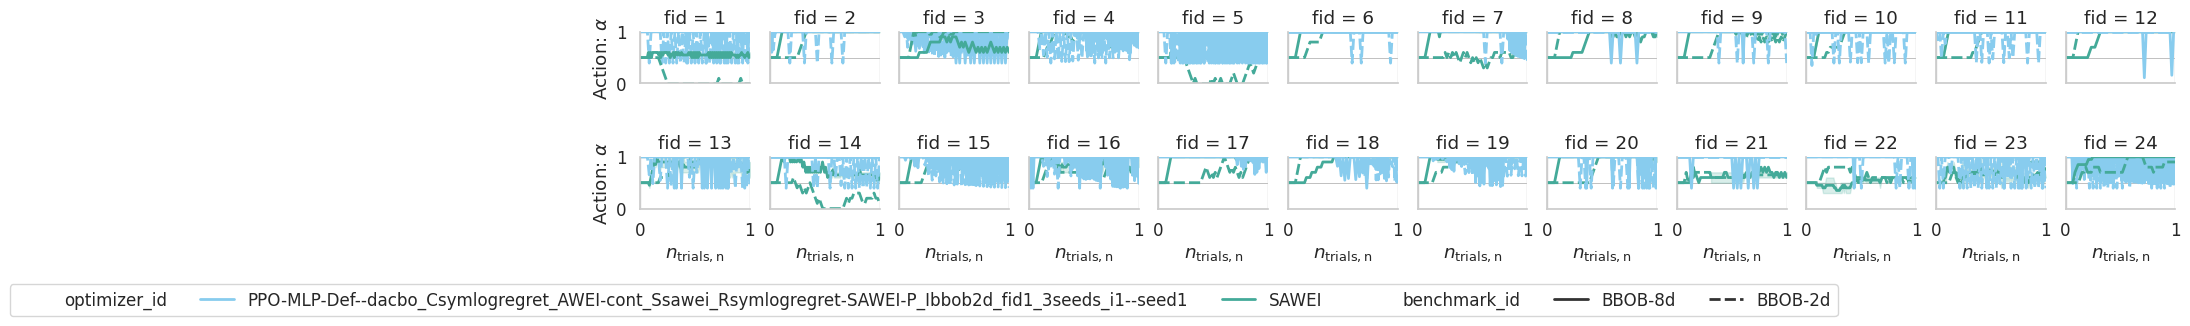

In [5]:

actions_to_plot = actions[actions["benchmark_id"].map(lambda x: x in {"BBOB-2d", "BBOB-8d"})].copy()
actions_to_plot["fid"] = actions_to_plot["task_id"].map(lambda x: int(x.split("/")[2]))
actions_to_plot["dim"] = actions_to_plot["task_id"].map(lambda x: x.split("/")[1])
actions_to_plot = actions_to_plot.sort_values(by="fid", ascending=True)

grid = sns.FacetGrid(data=actions_to_plot, col="fid", col_wrap=12, height=1.35, sharex=True)

for i, (fid, gdf) in enumerate(actions_to_plot.groupby("fid")):
    ax = grid.axes.flat[i]
    if i != 23 and False:
        continue
    ax.axhline(0.5, linestyle="-", linewidth=0.7, color="gray", zorder=0, alpha=0.5)
    ax = sns.lineplot(
        data=gdf,
        x="n_trials_norm", y="action",
        style="benchmark_id",
        hue="optimizer_id", palette=palette,
        linewidth=2,
        ax=ax
    )
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 1)
    ax.set_xticks([0,1])
    # ax.set_xlabel("$n_\mathrm{trials}$")
    ax.legend().remove()
    # if i == 0:
    #     ax.set_ylabel("Action: $\\alpha$")
    # else:
    #     ax.set_ylabel(None)
ax.legend(bbox_to_anchor=(-2,-1.3), ncols=10)
grid.set_xlabels("$n_\mathrm{trials,n}$")
grid.set_ylabels("Action: $\\alpha$")
grid.figure.subplots_adjust(wspace=0.18)
# grid.figure.tight_layout()
savefig(grid.figure, "figures/results_nips/alpha_bbob")
plt.show()

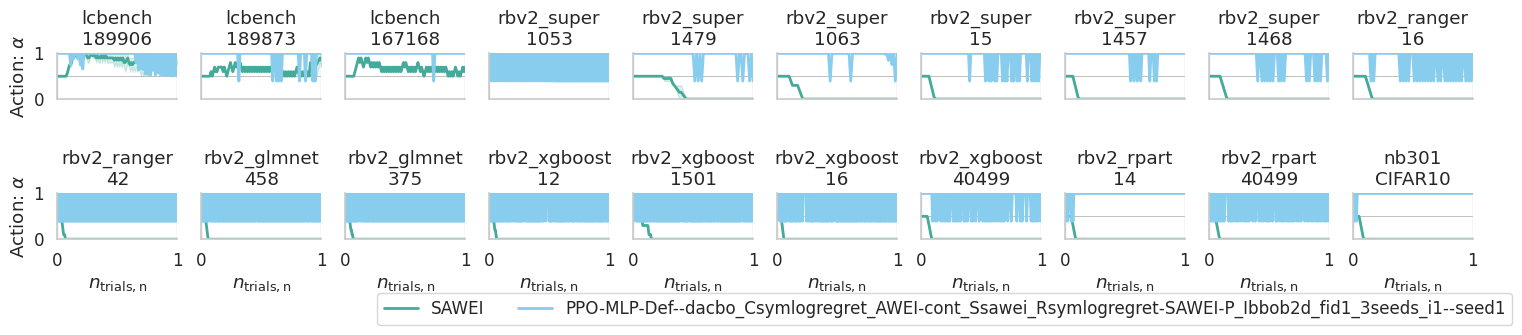

In [6]:

actions_to_plot = actions[actions["benchmark_id"].map(lambda x: x in {"YAHPO"})].copy()
def fix_yahpo_task_id(tid: str) -> str:
    return tid.replace("yahpo/so/", "").replace("/None", "").replace("/", "\n")
actions_to_plot["task_id"] = actions_to_plot["task_id"].map(fix_yahpo_task_id)

grid = sns.FacetGrid(data=actions_to_plot, col="task_id", col_wrap=10, height=1.5)

for i, (task_id, gdf) in enumerate(actions_to_plot.groupby("task_id")):
    if i != 19 and False:
        continue
    ax = grid.axes.flat[i]
    ax.axhline(0.5, linestyle="-", linewidth=0.7, color="gray", zorder=0, alpha=0.5)
    ax = sns.lineplot(
        data=gdf,
        x="n_trials_norm", y="action",
        # style="benchmark_id",
        hue="optimizer_id", palette=palette,
        linewidth=2,
        ax=ax
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([0,1])
    ax.legend().remove()
ax.legend(bbox_to_anchor=(1.4,-1), ncols=10)
grid.set_xlabels("$n_\mathrm{trials,n}$")
grid.set_ylabels("Action: $\\alpha$")
grid.set_titles(col_template="{col_name}")
# grid.figure.tight_layout()
grid.figure.subplots_adjust(wspace=0.2)
savefig(grid.figure, "figures/results_nips/alpha_yahpo")
plt.show()

['BBOB-2d' 'BBOB-8d' 'YAHPO']
BBOB-2d


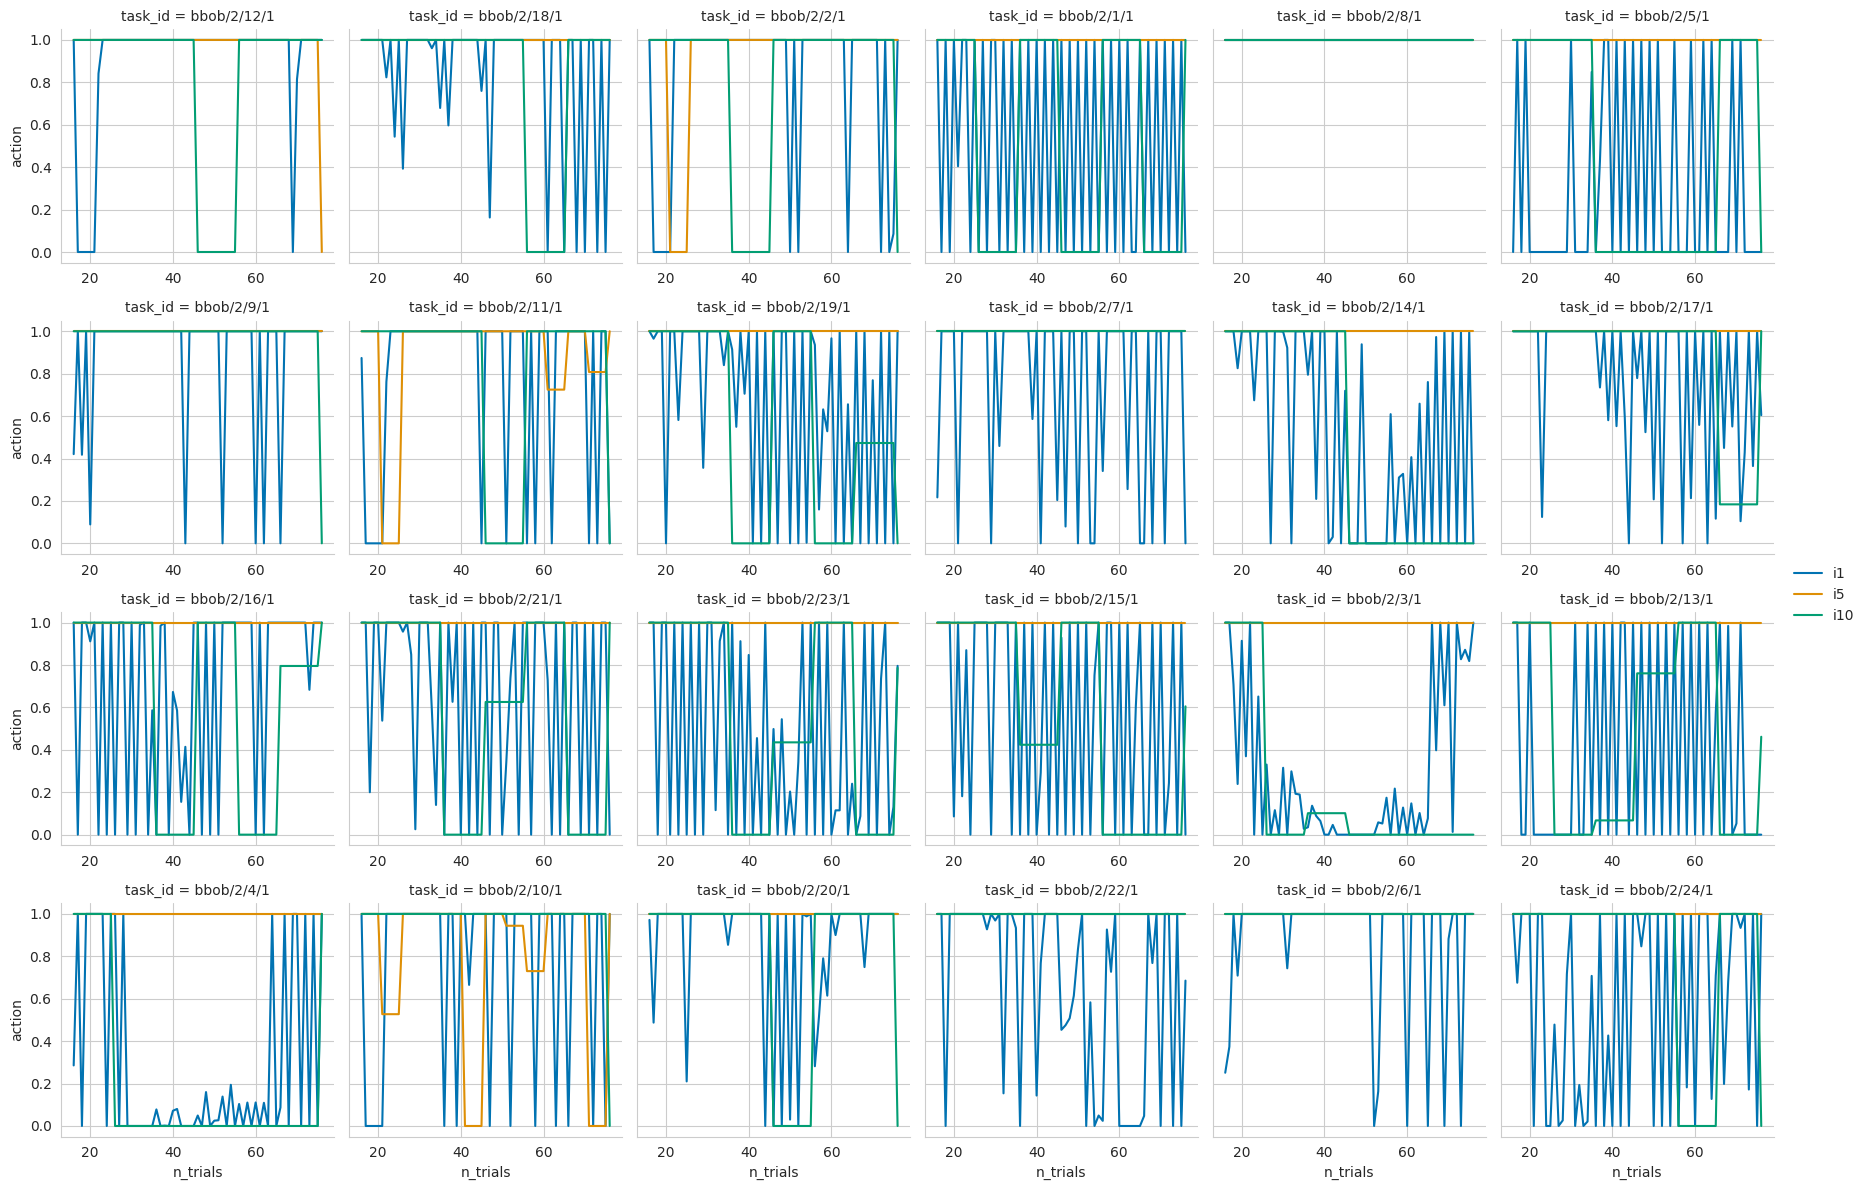

BBOB-8d


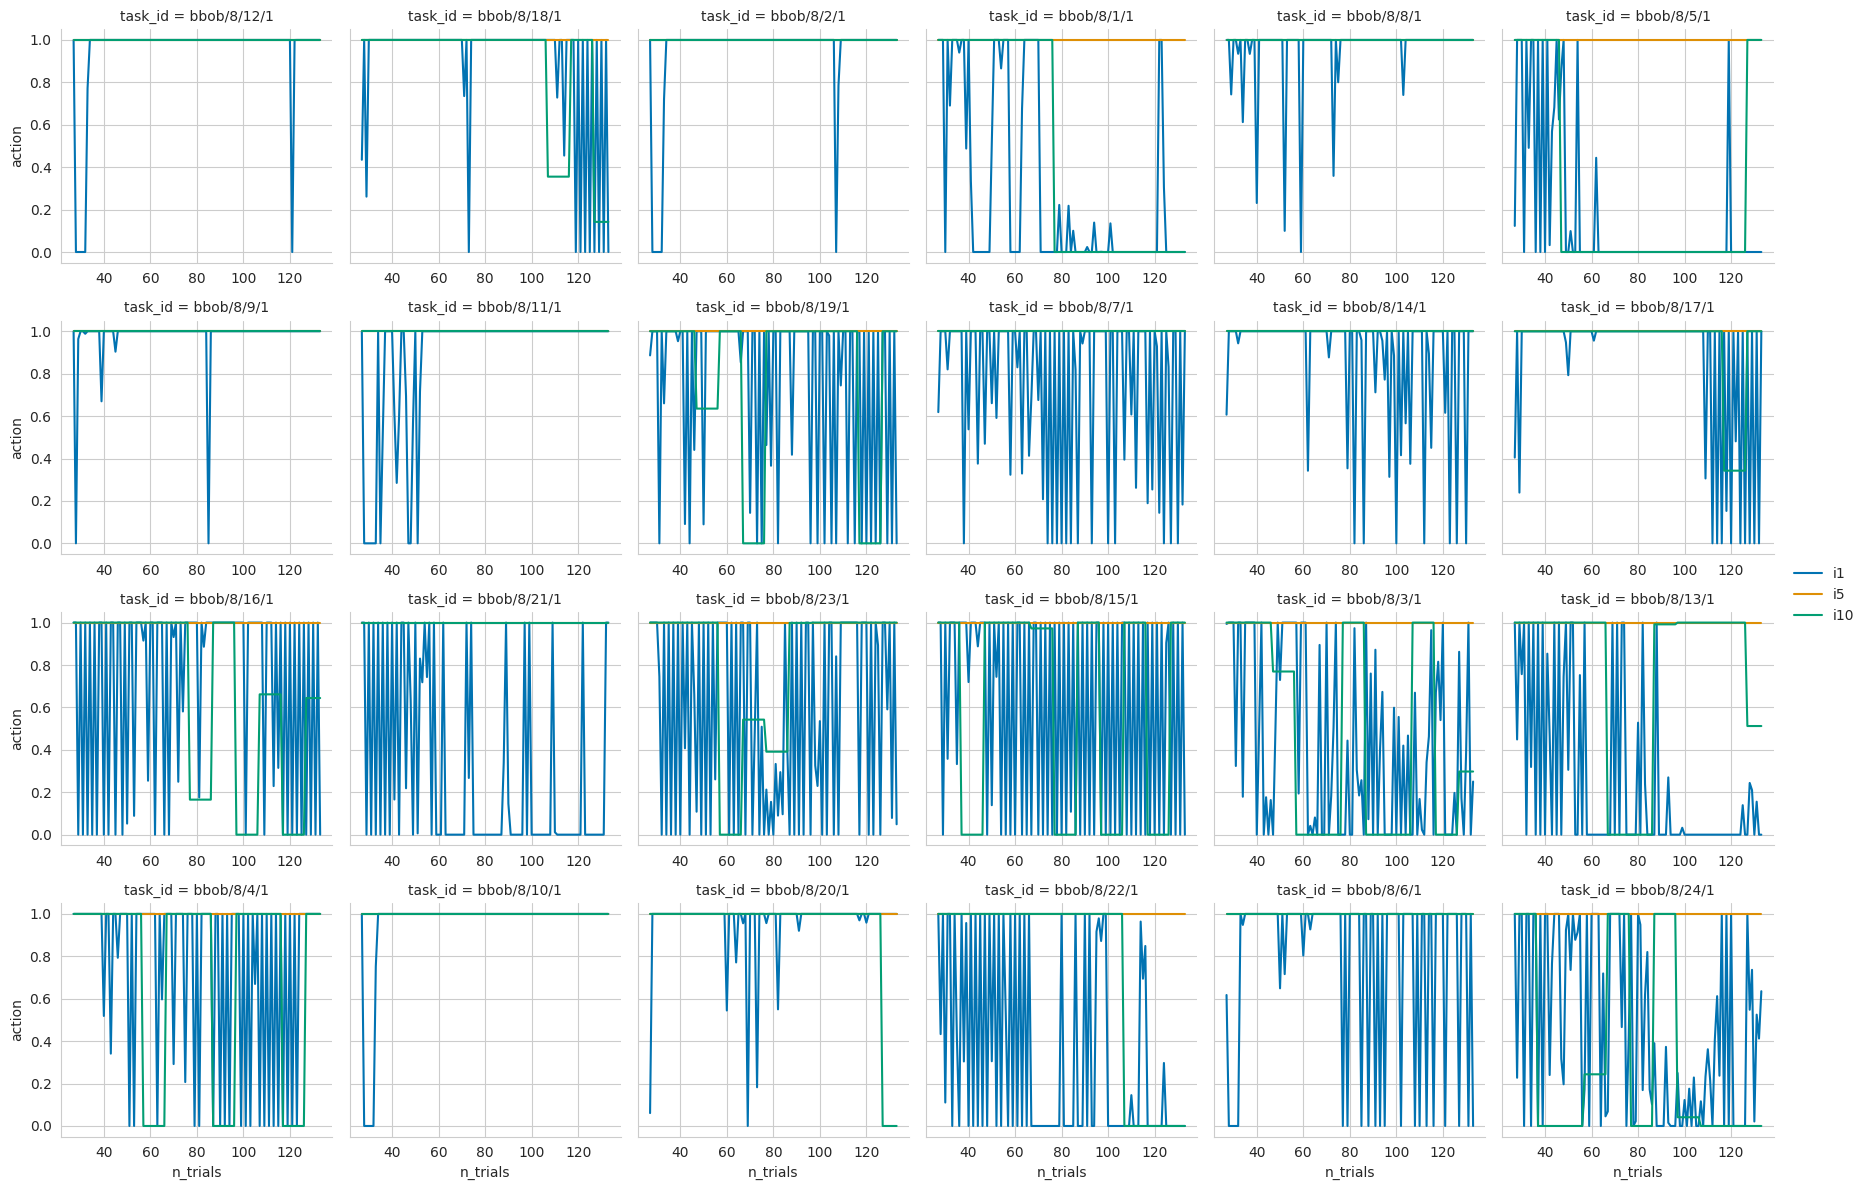

YAHPO


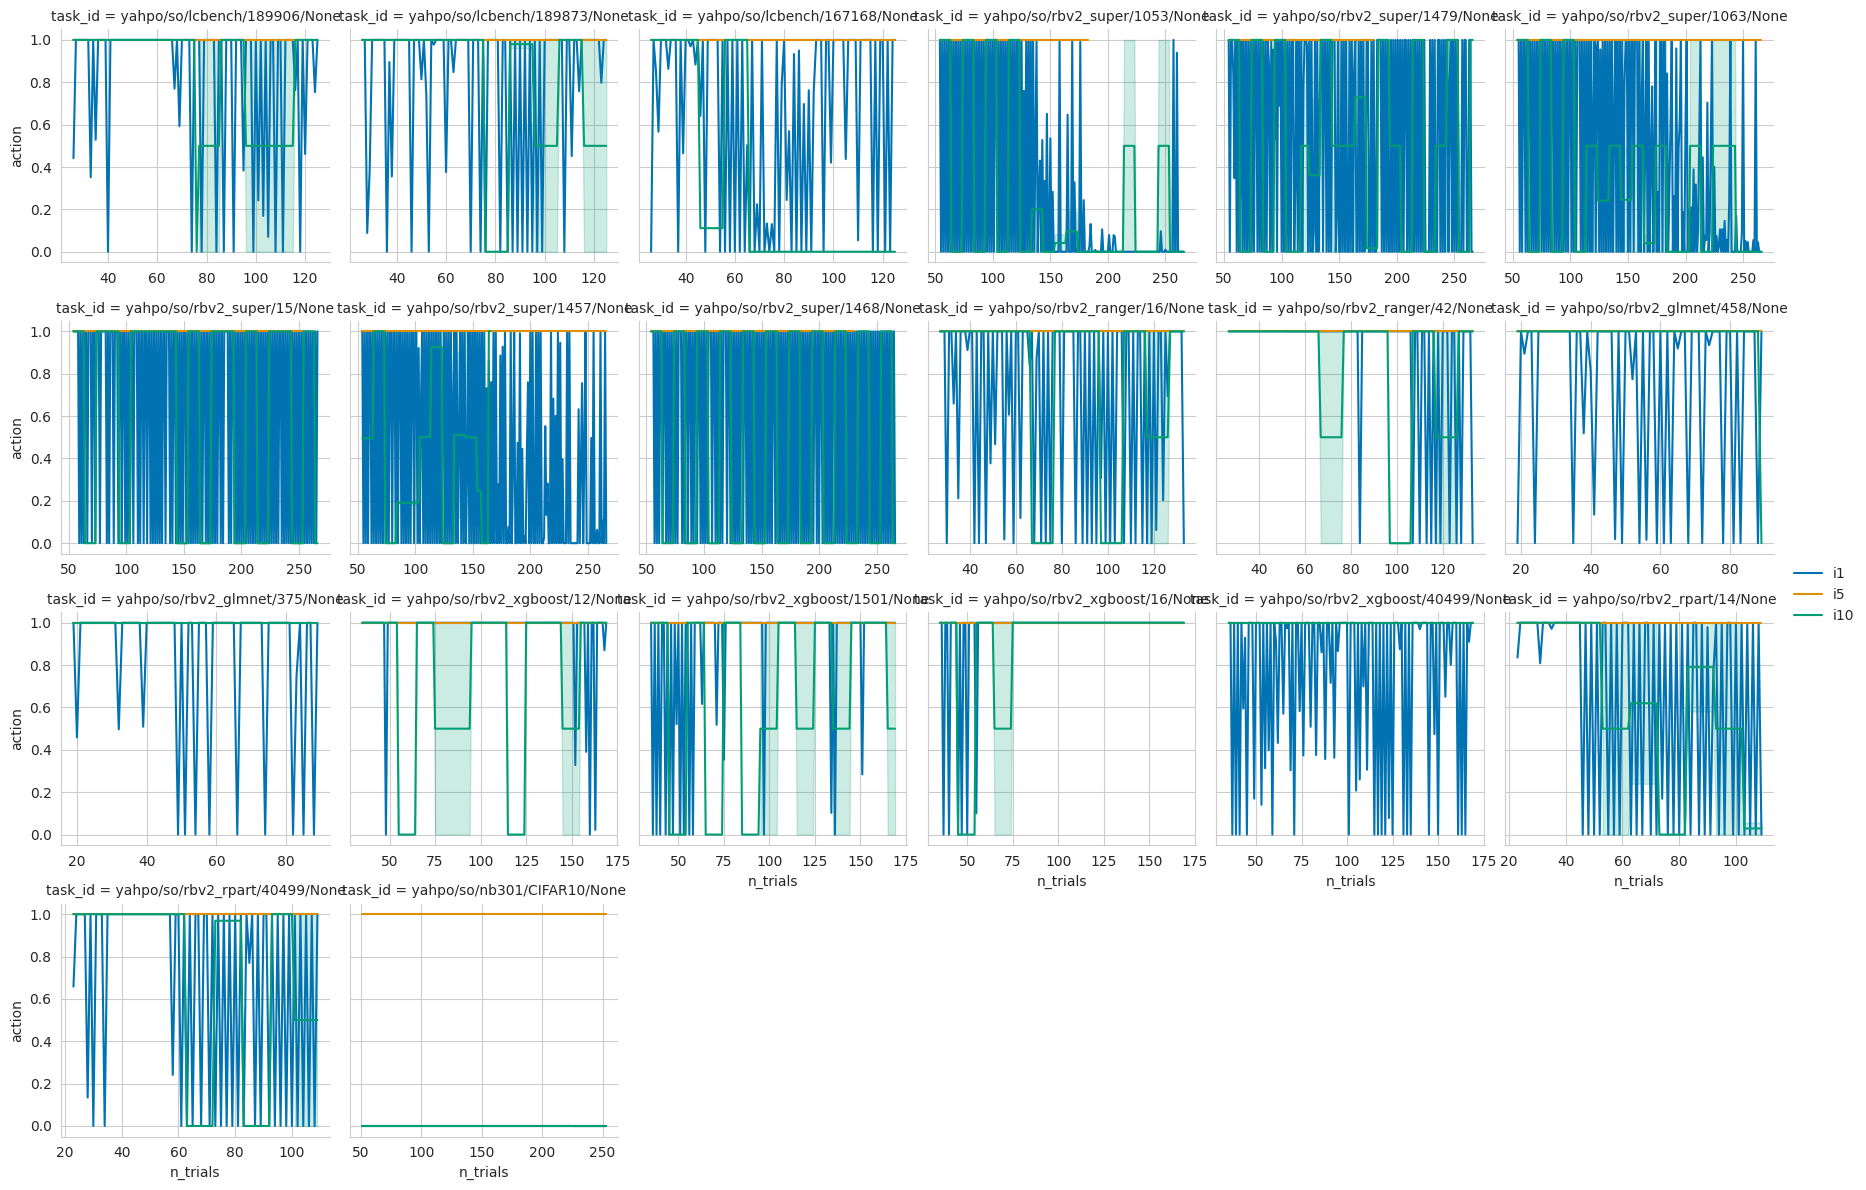

In [3]:

import seaborn as sns
import matplotlib.pyplot as plt
from carps.analysis.utils import setup_seaborn, get_color_palette, get_marker_palette
from carps.analysis.gather_data_utils import get_interpolated_performance_df
import pandas as pd

setup_seaborn()
%matplotlib inline

actions = pd.read_parquet("actions.parquet")
actions = postprocess_actions(actions)

policies_to_plot = [
    "PPO-MLP-Def--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid1_3seeds_i1--seed2",
    "PPO-MLP-Def--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid1_3seeds_i5--seed2",
    "PPO-MLP-Def--dacbo_Csymlogregret_AWEI-cont_Ssawei_Rsymlogregret-SAWEI-P_Ibbob2d_fid1_3seeds_i10--seed2",
]
actions_to_plot = actions[actions["policy_id"].isin(policies_to_plot)]
actions_to_plot = actions_to_plot[actions_to_plot["seed"] == 1]
actions_to_plot["policy_id"] = actions_to_plot["policy_id"].map(lambda x: x.split("--")[1].split("_")[-1])

for benchmark_id, gdf in actions_to_plot.groupby("benchmark_id"):
    print(benchmark_id)
    grid = sns.FacetGrid(data=gdf, col="task_id", col_wrap=6, sharex=False, sharey=True)
    grid.map_dataframe(sns.lineplot,
        # data=group[(group["seed"]==2) & (group["optimizer_id"].str.contains("fid8_3seeds--seed1"))],
        x="n_trials", y="action",# hue="task_id", palette=palette,
        hue="policy_id", palette="colorblind"
        # style="task_id", dashes=False, markers=marker_palette, markevery=10,
        # style="seed"
        )
    grid.add_legend()
    plt.show()
